# 05 — RF × 前処理の網羅比較

nb03はsnv+sg1固定、nb04はraw固定で前処理を固定していたため、
RFに対して前処理を体系的に比較する。

| 前処理 | 内容 |
|--------|------|
| raw | 無処理 |
| sg1 | 1次微分（ベースライン除去） |
| sg2 | 2次微分（ベースライン・線形傾き除去） |
| snv | 標準正規変量変換（散乱補正） |
| snv+sg1 | SNV → 1次微分 |
| snv+sg2 | SNV → 2次微分（定番手法） |
| msc+sg2 | MSC → 2次微分 |

> CVはすべてGroupKFold(species_number)で統一。

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

from src.utils import load_data, parse_spectra, get_groups, rmse, make_submission, setup_japanese_font
from src.preprocessing import apply_preprocessing, snv, msc, savitzky_golay

plt.rcParams['figure.dpi'] = 110
setup_japanese_font()

train_df, test_df = load_data()
train_meta, y_train, X_train_raw, wn = parse_spectra(train_df)
test_meta, _, X_test_raw, _ = parse_spectra(test_df)
groups = get_groups(train_meta)
y = y_train.values

N_SPLITS = 5
RF_PARAMS = dict(n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1)

print('train:', X_train_raw.shape, '  y range:', y.min(), '~', y.max())

train: (1322, 1555)   y range: 0.840336134 ~ 298.5815603


## 1. 前処理パターン定義

In [2]:
# msc+sg2 は apply_preprocessing に未実装のため個別定義
def preprocess(X, method):
    if method == 'msc+sg2':
        return savitzky_golay(msc(X), deriv=2)
    return apply_preprocessing(X, method=method)

METHODS = ['raw', 'sg1', 'sg2', 'snv', 'snv+sg1', 'snv+sg2', 'msc+sg2']

# 各前処理を事前に適用して辞書に格納
X_sets_train = {m: preprocess(X_train_raw, m) for m in METHODS}
X_sets_test  = {m: preprocess(X_test_raw,  m) for m in METHODS}

print('前処理完了:', METHODS)

前処理完了: ['raw', 'sg1', 'sg2', 'snv', 'snv+sg1', 'snv+sg2', 'msc+sg2']


## 2. RF × 前処理 CV比較

In [3]:
results = {}

for method in METHODS:
    X = X_sets_train[method]
    scores = []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        rf = RandomForestRegressor(**RF_PARAMS)
        rf.fit(X[tr], y[tr])
        scores.append(rmse(y[va], rf.predict(X[va])))
    mean_rmse = np.mean(scores)
    std_rmse  = np.std(scores)
    results[method] = {'mean': mean_rmse, 'std': std_rmse, 'folds': scores}
    print(f'{method:12s}  CV RMSE = {mean_rmse:.4f} ± {std_rmse:.4f}')

summary = pd.DataFrame({m: {'CV RMSE': v['mean'], 'std': v['std']} for m, v in results.items()}).T
summary = summary.sort_values('CV RMSE')
print('\n=== 順位 ===')
print(summary.to_string(float_format='{:.4f}'.format))

raw           CV RMSE = 53.9722 ± 53.9252
sg1           CV RMSE = 21.9931 ± 14.2543
sg2           CV RMSE = 20.2211 ± 9.6127
snv           CV RMSE = 23.9893 ± 12.7375
snv+sg1       CV RMSE = 20.1910 ± 11.3458
snv+sg2       CV RMSE = 18.7057 ± 9.9367
msc+sg2       CV RMSE = 18.1486 ± 8.3882

=== 順位 ===
         CV RMSE     std
msc+sg2  18.1486  8.3882
snv+sg2  18.7057  9.9367
snv+sg1  20.1910 11.3458
sg2      20.2211  9.6127
sg1      21.9931 14.2543
snv      23.9893 12.7375
raw      53.9722 53.9252


## 3. 結果の可視化

C:\Users\rikky\AppData\Local\Temp\ipykernel_17864\1353991653.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(fold_data, vert=False, labels=summary.index, patch_artist=True)


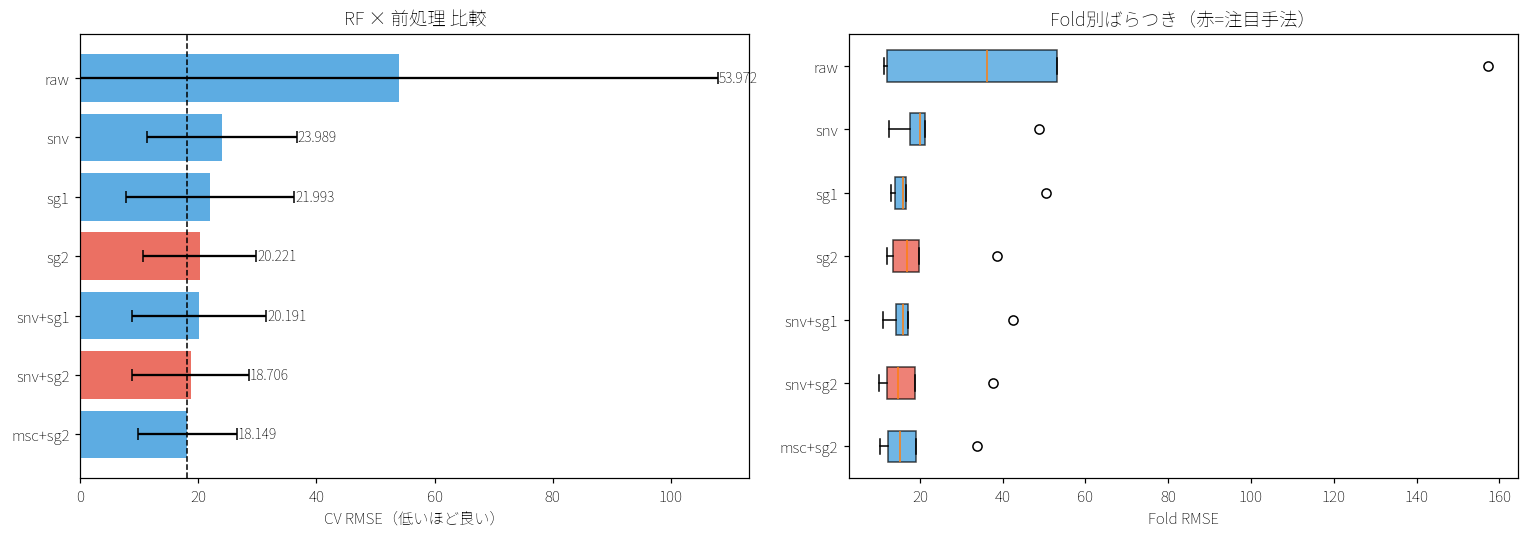

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 棒グラフ（平均RMSE + 標準偏差）
ax = axes[0]
colors = ['#e74c3c' if m in ('sg2', 'snv+sg2') else '#3498db' for m in summary.index]
bars = ax.barh(summary.index, summary['CV RMSE'], xerr=summary['std'],
               color=colors, alpha=0.8, capsize=4)
ax.axvline(summary['CV RMSE'].iloc[0], color='black', linestyle='--', linewidth=1)
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('RF × 前処理 比較')
for i, (_, row) in enumerate(summary.iterrows()):
    ax.text(row['CV RMSE'] + row['std'] + 0.1, i, f"{row['CV RMSE']:.3f}", va='center', fontsize=9)

# Fold別スコアのボックスプロット
ax2 = axes[1]
fold_data = [results[m]['folds'] for m in summary.index]
bp = ax2.boxplot(fold_data, vert=False, labels=summary.index, patch_artist=True)
for patch, m in zip(bp['boxes'], summary.index):
    patch.set_facecolor('#e74c3c' if m in ('sg2', 'snv+sg2') else '#3498db')
    patch.set_alpha(0.7)
ax2.set_xlabel('Fold RMSE')
ax2.set_title('Fold別ばらつき（赤=注目手法）')

plt.tight_layout()
plt.show()

## 4. 上位2手法で平方根変換の効果を確認

nb04でrawに対して試したsqrt変換を、今回の上位手法にも適用する。

In [5]:
y_sqrt = np.sqrt(y)
top2_methods = list(summary.index[:2])

sqrt_results = {}
for method in top2_methods:
    X = X_sets_train[method]
    scores = []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        rf = RandomForestRegressor(**RF_PARAMS)
        rf.fit(X[tr], y_sqrt[tr])
        pred = np.square(rf.predict(X[va])).clip(min=0)
        scores.append(rmse(y[va], pred))
    mean_r = np.mean(scores)
    sqrt_results[f'{method}+sqrt'] = mean_r
    base_r = results[method]['mean']
    print(f'{method}+sqrt  CV RMSE = {mean_r:.4f}  (vs base: {mean_r - base_r:+.4f})')

msc+sg2+sqrt  CV RMSE = 17.8126  (vs base: -0.3360)
snv+sg2+sqrt  CV RMSE = 18.0771  (vs base: -0.6286)


## 5. 最良設定で提出ファイル生成

In [6]:
# 全結果をまとめて最良を選択
all_results = {m: results[m]['mean'] for m in METHODS}
all_results.update(sqrt_results)

best_key = min(all_results, key=all_results.get)
best_rmse_val = all_results[best_key]
print(f'最良: {best_key}  CV RMSE = {best_rmse_val:.4f}')

# 最良設定で全訓練データを使って再学習
use_sqrt = '+sqrt' in best_key
base_method = best_key.replace('+sqrt', '')

X_tr_best = X_sets_train[base_method]
X_te_best = X_sets_test[base_method]

rf_final = RandomForestRegressor(**RF_PARAMS)
if use_sqrt:
    rf_final.fit(X_tr_best, y_sqrt)
    test_pred = np.square(rf_final.predict(X_te_best)).clip(min=0)
else:
    rf_final.fit(X_tr_best, y)
    test_pred = rf_final.predict(X_te_best)

print(f'テスト予測: min={test_pred.min():.2f}  max={test_pred.max():.2f}  mean={test_pred.mean():.2f}')

suffix = best_key.replace('+', '_').replace('/', '_')
sub = make_submission(test_meta, test_pred, path=f'../submissions/rf_{suffix}.csv')
print(f'提出ファイル: ../submissions/rf_{suffix}.csv')
sub.head(10)

最良: msc+sg2+sqrt  CV RMSE = 17.8126
テスト予測: min=10.95  max=168.14  mean=48.84
Saved submission: ../submissions/rf_msc_sg2_sqrt.csv
提出ファイル: ../submissions/rf_msc_sg2_sqrt.csv


,sample_number,moisture
0,95,164.945481
1,96,159.285494
2,97,166.393441
3,98,156.809861
4,99,153.558379
5,100,156.091928
6,101,147.549259
7,102,147.736258
8,103,146.637286
9,104,138.578719
